# jval_explorer — demand ↔ Jacobian, and clustering under the physics

Companion to `jval_lab`. That notebook scores; this one lets you *look*.
Two things, both interactive:

1. **Demand ↔ Jacobian.** The forward map $y = J^{\mathrm d}D$ and the inverse
   $\hat D = (J^{\mathrm d})^{+}(y-\bar y)$, sensor by sensor and district by
   district. Forward and inverse are separated on purpose: a forward failure
   localises the problem to the Jacobian or the node weights, an
   inverse-only failure to conditioning.
2. **Clustering.** Districts clustered on $\rho$ from three signals — the true
   demand (ceiling), the unmixed estimate (the claim), the raw sensors (the
   confounded baseline) — with a month slider so the drifting district can be
   watched migrating between clusters, and `J_perm` as the control that must
   collapse.

Every cluster panel scores against **two** label sets: the regime labels and
adjacency. High on regime *and* low on adjacency is the de-confounding claim.
The reverse is the physics confound reasserting itself, which is exactly what
happened to the federated artifacts.

Requires `ipywidgets`. In VS Code the matplotlib backend needs `plt.show()`
explicitly, which every callback below does.

In [2]:
import sys, pathlib, copy
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import wntr, yaml

HERE = pathlib.Path.cwd().resolve()
PROJ = next((p for p in [HERE, *HERE.parents] if (p / "pyproject.toml").exists()), HERE)
for p in (PROJ / "src", PROJ / "notebooks", PROJ, HERE):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

In [3]:
# =====================================================================
# 0. setup -- reads the world set pinned by jval_lab
# =====================================================================
import sys, pathlib, warnings
import numpy as np, pandas as pd, yaml
import matplotlib.pyplot as plt
import ipywidgets as W
from IPython.display import display

PROJ = pathlib.Path.home() / "USPy/10_Mestrado/fedWater"      # <-- adjust
sys.path.insert(0, str(PROJ / "notebooks" / "SensorPlacement"))
import placement_poc as P
import jval_engine as J

OUT = PROJ / "data/08_reporting/jval"
PIN = OUT / "pinned_worlds.csv"

IDX = J.jval_index(PROJ, n_months=48)
if PIN.exists():                       # reuse jval_lab's pinned set
    keep = pd.read_csv(PIN)["sim_hash"].astype(str).tolist()
    LAB = J.label_arms(IDX)
    WORLDS = LAB[LAB.sim_hash.isin(keep)].reset_index(drop=True)
else:                                  # or re-derive it
    G = J.gate_table(IDX, yaml.safe_load(
        (PROJ / "data/01_raw/districts_graeme.yml").read_text()))
    WORLDS = J.pin(J.label_arms(IDX, onset=G.set_index("sim_hash")["onset"]), G)

DISTRICTS = yaml.safe_load((PROJ / "data/01_raw/districts_graeme.yml").read_text())
DS = sorted(DISTRICTS["districts"])
ARMS = ("J_inp", "J_pre", "J_post", "J_perm")

_VIEWS: dict = {}


def view(sim_hash, placement="variance"):
    """One WorldView per (world, placement), cached -- the perturbation
    sweep is 113 solves and must not re-run on a slider drag."""
    key = (sim_hash, placement)
    if key not in _VIEWS:
        w = WORLDS[WORLDS.sim_hash == sim_hash].iloc[0]
        _VIEWS[key] = J.WorldView(w, DISTRICTS, placement=placement, arms=ARMS)
    return _VIEWS[key]


# CLIENT_INITstate_FINALstate__MAPPING__HASH6_EXPERIMENT
# e.g. E_LI_LR__LI_LI_LR_LR_LI__dqw34q_oddone
LABELS = dict(sorted((J.world_label(r, DISTRICTS), r.sim_hash)
                     for _, r in WORLDS.iterrows()))
TITLE = {h: J.plot_title(WORLDS[WORLDS.sim_hash == h].iloc[0], DISTRICTS)
         for h in LABELS.values()}


def sup(fig, sim_hash, extra="", tight=True):
    """Every figure carries the same header: who drifts, from what to what,
    and the commissioning map with the drifter's token bracketed.

    `tight=False` for figures with a colorbar spanning several axes, where
    tight_layout cannot lay the grid out and warns instead.
    """
    t = TITLE[sim_hash] + (("\n" + extra) if extra else "")
    fig.suptitle(t, fontsize=9, family="monospace", ha="center")
    top = 0.99 - 0.055 * t.count("\n")
    if tight:
        plt.tight_layout(rect=(0, 0, 1, top))
    else:
        fig.subplots_adjust(top=top)


print(f"{len(WORLDS)} worlds | arms {sorted(WORLDS.arm.unique())}")
for k in list(LABELS)[:6]:
    print("  ", k)

40 worlds | arms ['beta', 'coupling', 'income', 's1_oddone', 's2_split']
   A_LR_LI__LR_LR_LR_LI_LI__299af9_split
   A_LR_LI__LR_LR_LR_LI_LI__321c58_split
   A_LR_LI__LR_LR_LR_LI_LI__4b080c_split
   A_LR_LI__LR_LR_LR_LR_LI__249746_oddone
   A_LR_LI__LR_LR_LR_LR_LI__74e5d1_coupling
   A_LR_LI__LR_LR_LR_LR_LI__b472a1_coupling


## 1. The mixing matrix

$J^{\mathrm d}$ is $15\times 5$: rows are sensors, columns districts, entry
$s,k$ the flow response at sensor $s$ to a unit demand change in district $k$.
A column that is nearly a multiple of another means those two districts are
hard to tell apart from these sensors — that is what $\sigma_{\min}$ measures,
and why unmixing error scales as $1/\sigma_{\min}$.

Compare arms: `J_inp` and `J_pre` differ only in the operating point and the
node weights, `J_perm` is `J_pre` with the columns shuffled.

In [ ]:
# =====================================================================
# 1. Jd heatmap + conditioning
# =====================================================================
def show_jd(sim_hash, placement, arm):
    v = view(sim_hash, placement)
    Jd = v.Jd[arm]
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2),
                           gridspec_kw=dict(width_ratios=[2, 1]))
    im = ax[0].imshow(Jd.to_numpy(), aspect="auto", cmap="RdBu_r",
                      vmin=-np.abs(Jd.to_numpy()).max(),
                      vmax=np.abs(Jd.to_numpy()).max())
    ax[0].set(xticks=range(len(Jd.columns)), yticks=range(len(Jd.index)),
              title=f"$J^d$  {arm}  ({placement})")
    ax[0].set_xticklabels([c[-1] for c in Jd.columns])
    ax[0].set_yticklabels(Jd.index, fontsize=7)
    plt.colorbar(im, ax=ax[0], fraction=.046)

    sv = np.linalg.svd(Jd.to_numpy(), compute_uv=False)
    ax[1].bar(range(1, len(sv) + 1), sv)
    q = J._quality(Jd)
    ax[1].set(xlabel="index", ylabel="singular value",
              title=f"cond {q['cond']:.2f} | $\\sigma_{{min}}$ "
                    f"{q['sigma_min']:.4f}")
    ax[1].grid(alpha=.3, axis="y")
    sup(fig, sim_hash, f"$J^d$  {arm}   ({placement})")
    plt.show()
    display(v.diag[["arm", "probe", "delta", "op_total", "baseline_min_p",
                    "cond", "sigma_min"]].round(5))


W.interact(show_jd,
           sim_hash=W.Dropdown(options=LABELS, description="world"),
           placement=W.Dropdown(options=list(J.PLACEMENTS_ALL),
                                value="variance", description="placement"),
           arm=W.Dropdown(options=list(ARMS), value="J_pre", description="arm"));

## 2. Forward check — does $y = J^{\mathrm d}D$ actually hold?

This is the model, not the inverse. Take the **true** district demand, push it
through $J^{\mathrm d}$, and compare against the measured sensor series on the
same window. If these track, the linearisation and the proportional-weights
assumption $d_{i,t}=D_{k,t}w_{k,i}$ both hold on this window.

Where it should fail: `transition`, because mid-conversion the drifting
district's internal shares are time-varying and spatially clustered, so
$w_k$ is wrong in exactly the way that hurts. Pick a sensor near the drifting
district and step the window.

In [ ]:
# =====================================================================
# 2. forward reconstruction, per sensor
# =====================================================================
def show_forward(sim_hash, placement, arm, window, sensor_i, n_steps):
    v = view(sim_hash, placement)
    pred, act = v.reconstruct(arm, window)
    c = act.columns[min(sensor_i, len(act.columns) - 1)]
    r = float(np.corrcoef(pred[c], act[c])[0, 1])
    sc = float(act[c].std() / pred[c].std()) if pred[c].std() else np.nan

    fig, ax = plt.subplots(1, 3, figsize=(15, 3.4),
                           gridspec_kw=dict(width_ratios=[2, 1, 1]))
    k = min(n_steps, len(act))
    ax[0].plot(act[c].to_numpy()[:k], lw=.9, label="measured $y$")
    ax[0].plot(pred[c].to_numpy()[:k], lw=.9, label="$J^d D_{true}$")
    ax[0].set(title=f"sensor {c} | {window} | r={r:.4f} scale={sc:.3f}",
              xlabel="step (hours)", ylabel="deviation from mean")
    ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

    ax[1].scatter(pred[c], act[c], s=2, alpha=.25)
    lim = [min(pred[c].min(), act[c].min()), max(pred[c].max(), act[c].max())]
    ax[1].plot(lim, lim, "k--", lw=.8)
    ax[1].set(xlabel="predicted", ylabel="measured", title="forward fit")
    ax[1].grid(alpha=.3)

    fr = v.fit_report(arm, window)
    s = fr[fr.kind == "sensor"]
    ax[2].barh(range(len(s)), s["fit_corr"].values)
    ax[2].set(yticks=range(len(s)), xlabel="corr(pred, meas)",
              title="all sensors", xlim=(min(0, s["fit_corr"].min()), 1.02))
    ax[2].set_yticklabels(s["element"], fontsize=6)
    ax[2].axvline(1.0, color="k", lw=.6); ax[2].grid(alpha=.3, axis="x")
    sup(fig, sim_hash, f"FORWARD  $y = J^d D_{{true}}$   |   {arm}   |   "
                       f"{window} window")
    plt.show()


W.interact(show_forward,
           sim_hash=W.Dropdown(options=LABELS, description="world"),
           placement=W.Dropdown(options=list(J.PLACEMENTS_ALL),
                                value="variance", description="placement"),
           arm=W.Dropdown(options=list(ARMS), value="J_pre", description="arm"),
           window=W.Dropdown(options=["pre", "transition", "post"],
                             description="window"),
           sensor_i=W.IntSlider(0, 0, 14, description="sensor #"),
           n_steps=W.IntSlider(720, 168, 4320, step=168, description="steps"));

## 3. Inverse check — reconstruction of district demand

Now the direction that matters: $\hat D = (J^{\mathrm d})^{+}(y-\bar y)$ against
the true district demand.

Read two things separately, because M1 and M2 are orthogonal:

* **shape** — the correlation of $\hat D_k$ with $D_k$, and their overlaid
  series. This is what M1 uses and what land use writes into.
* **amplitude** — the ratio $\operatorname{sd}(\hat D_k)/\operatorname{sd}(D_k)$,
  i.e. $e^{r_k}$. This is what M2 uses and what income writes into. A single
  common factor across all five districts is unidentifiable and harmless;
  *spread* across districts is the error.

In [ ]:
# =====================================================================
# 3. inverse reconstruction, per district
# =====================================================================
def show_inverse(sim_hash, placement, arm, window, district, n_steps, normalise):
    v = view(sim_hash, placement)
    Dt, Dh = v.truth(window), v.unmixed(arm, window)
    Dh.index = Dt.index
    a, b = Dt[district].to_numpy(), Dh[district].to_numpy()
    if normalise:
        b = b * (a.std() / b.std() if b.std() else 1.0)
    k = min(n_steps, len(a))

    fig, ax = plt.subplots(1, 3, figsize=(15, 3.4),
                           gridspec_kw=dict(width_ratios=[2, 1, 1]))
    ax[0].plot(a[:k] - a.mean(), lw=.9, label="$D_{true}$")
    ax[0].plot(b[:k] - b.mean(), lw=.9, label="$\\hat D$")
    ax[0].set(title=f"{district} | {window} | "
                    f"r={np.corrcoef(a, b)[0,1]:.4f}",
              xlabel="step (hours)", ylabel="demand deviation (L/s)")
    ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

    ax[1].scatter(a, b, s=2, alpha=.25)
    ax[1].set(xlabel="$D_{true}$", ylabel="$\\hat D$", title="inverse fit")
    ax[1].grid(alpha=.3)

    fr = v.fit_report(arm, window)
    d = fr[fr.kind == "district"]
    x = np.arange(len(d))
    ax[2].bar(x - .2, d["fit_corr"].values, .4, label="corr (shape / M1)")
    ax[2].bar(x + .2, d["sd_ratio"].values, .4, label="sd ratio (level / M2)")
    ax[2].axhline(1.0, color="k", lw=.6)
    ax[2].set(xticks=x, title="per district", ylim=(0, max(1.4, d["sd_ratio"].max())))
    ax[2].set_xticklabels([n[-1] for n in d["element"]])
    ax[2].legend(fontsize=7); ax[2].grid(alpha=.3, axis="y")
    sup(fig, sim_hash, f"INVERSE  $\\hat D = (J^d)^+(y-\\bar y)$   |   {arm}"
                       f"   |   {window} window")
    plt.show()
    print(f"sd-ratio spread across districts (M2 error) = "
          f"{np.log(d['sd_ratio'].values).std():.4f}   "
          f"common factor (unidentifiable) = {np.log(d['sd_ratio'].values).mean():+.4f}")


W.interact(show_inverse,
           sim_hash=W.Dropdown(options=LABELS, description="world"),
           placement=W.Dropdown(options=list(J.PLACEMENTS_ALL),
                                value="variance", description="placement"),
           arm=W.Dropdown(options=list(ARMS), value="J_pre", description="arm"),
           window=W.Dropdown(options=["pre", "transition", "post"],
                             description="window"),
           district=W.Dropdown(options=DS, description="district"),
           n_steps=W.IntSlider(720, 168, 4320, step=168, description="steps"),
           normalise=W.Checkbox(True, description="match sd"));

## 4. Pre vs post — the whole argument in one grid

Rows are the two clean windows and their difference; columns are the three
signals. $\rho$ from the true district demand (what we want), from the unmixed
estimate (what we get), and from the raw sensors aggregated per district (what
an observational method sees).

Read it in two passes.

**Down the columns.** The raw panel is the confound made visible: pairs read as
strongly coupled because they share pipes, not because they share a regime.
That is why every observational sector test, drift attribution and Granger
direction came back null — the estimand was never $\rho(D_a,D_b)$.

**Along the $\Delta$ row.** $\rho_{\text{post}} - \rho_{\text{pre}}$ is the
signed effect of a known intervention. The drifter's row and column are boxed:
its pairs with the sector it *joins* must go up, its pairs with the sector it
*leaves* must go down, and every pair not involving it must stay at zero — that
last one is the invariance null, and any colour there is pure method error. The
scatter puts $\Delta\rho_{\text{true}}$ against $\Delta\hat\rho$ for all ten
pairs, so P3 (the cluster at the origin) and P4 (the two off-origin arms) are
one picture.

In [ ]:
# =====================================================================
# 4. rho pre / post / delta  x  true / unmixed / raw
# =====================================================================
def show_rhos(sim_hash, placement, arm):
    v = view(sim_hash, placement)
    kinds = ["truth", "unmixed", "raw"]
    drift = v.w["drift_district"]
    di = DS.index(drift)
    M = {(k, win): v.rho(k, arm, win) for k in kinds for win in ("pre", "post")}

    fig, ax = plt.subplots(3, 3, figsize=(11.5, 10.2))
    for c, k in enumerate(kinds):
        for r, win in enumerate(("pre", "post")):
            m = M[(k, win)]
            ax[r, c].imshow(m.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
            ax[r, c].set_title(f"{k} — {win}", fontsize=9)
            for i in range(5):
                for j in range(5):
                    ax[r, c].text(j, i, f"{m.iloc[i,j]:.2f}", ha="center",
                                  va="center", fontsize=6)
        d = M[(k, "post")] - M[(k, "pre")]
        im = ax[2, c].imshow(d.to_numpy(), vmin=-1, vmax=1, cmap="PuOr_r")
        ax[2, c].set_title(f"$\\Delta$ {k}  (post - pre)", fontsize=9)
        for i in range(5):
            for j in range(5):
                ax[2, c].text(j, i, f"{d.iloc[i,j]:+.2f}", ha="center",
                              va="center", fontsize=6)
        # box the drifter: everything outside its row/col must be ~0
        for a_ in (ax[0, c], ax[1, c], ax[2, c]):
            a_.add_patch(plt.Rectangle((-.5, di - .5), 5, 1, fill=False,
                                       ec="k", lw=1.4))
            a_.add_patch(plt.Rectangle((di - .5, -.5), 1, 5, fill=False,
                                       ec="k", lw=1.4))
    for a_ in ax.ravel():
        a_.set(xticks=range(5), yticks=range(5))
        a_.set_xticklabels([c[-1] for c in DS], fontsize=7)
        a_.set_yticklabels([c[-1] for c in DS], fontsize=7)
    plt.colorbar(im, ax=ax[2, :].tolist(), fraction=.025)
    sup(fig, sim_hash, f"SIMILARITY  pre / post / delta   |   {arm}   |   "
                       f"boxed = drifter {drift[-1]}", tight=False)
    plt.show()

    # the signed-change picture: P3 at the origin, P4 in the arms
    pairs = [(a, b) for i, a in enumerate(DS) for b in DS[i + 1:]]
    dt = np.array([(M[("truth", "post")].loc[a, b]
                    - M[("truth", "pre")].loc[a, b]) for a, b in pairs])
    fig2, ax2 = plt.subplots(1, 2, figsize=(11, 3.8))
    for k, mk in (("unmixed", "o"), ("raw", "x")):
        dh = np.array([(M[(k, "post")].loc[a, b]
                        - M[(k, "pre")].loc[a, b]) for a, b in pairs])
        inv = np.array([drift not in p for p in pairs])
        ax2[0].scatter(dt[~inv], dh[~inv], marker=mk, s=55,
                       label=f"{k} · drifter pairs")
        ax2[0].scatter(dt[inv], dh[inv], marker=mk, s=25, alpha=.45,
                       label=f"{k} · invariance null "
                             f"(|max| {np.abs(dh[inv]).max():.3f})")
    ax2[0].axhline(0, color="k", lw=.6); ax2[0].axvline(0, color="k", lw=.6)
    lim = 1.05 * max(1e-3, np.abs(dt).max())
    ax2[0].plot([-lim, lim], [-lim, lim], "k--", lw=.8)
    ax2[0].set(xlabel=r"$\Delta\rho$ true", ylabel=r"$\Delta\rho$ estimated",
               title="signed change, 10 pairs")
    ax2[0].legend(fontsize=7); ax2[0].grid(alpha=.3)

    # level, pre vs post, per district -- the axis M1 cannot see
    fr = {win: v.fit_report(arm, win) for win in ("pre", "post")}
    x = np.arange(5)
    for o, win in ((-.2, "pre"), (.2, "post")):
        d = fr[win][fr[win].kind == "district"]
        ax2[1].bar(x + o, d["sd_ratio"].values, .4, label=f"{win}")
    ax2[1].axhline(1.0, color="k", lw=.6)
    ax2[1].set(xticks=x, ylabel=r"$sd(\hat D)/sd(D)$",
               title="amplitude recovery (M2), pre vs post")
    ax2[1].set_xticklabels([c[-1] for c in DS])
    ax2[1].legend(fontsize=8); ax2[1].grid(alpha=.3, axis="y")
    sup(fig2, sim_hash, f"SIGNED CHANGE and LEVEL   |   {arm}")
    plt.show()

    rows = []
    for k in kinds:
        for win in ("pre", "post"):
            t = M[("truth", win)]
            e = M[(k, win)]
            rows.append(dict(signal=k, window=win, mae=float(np.mean(
                [abs(e.loc[a, b] - t.loc[a, b]) for a, b in pairs]))))
    display(pd.DataFrame(rows).pivot(index="signal", columns="window",
                                     values="mae").round(4))


W.interact(show_rhos,
           sim_hash=W.Dropdown(options=LABELS, description="world"),
           placement=W.Dropdown(options=list(J.PLACEMENTS_ALL),
                                value="variance", description="placement"),
           arm=W.Dropdown(options=list(ARMS), value="J_pre", description="arm"));

## 5. Clustering, month by month

The federated task is similarity: group clients whose demand behaves alike, so
that personalisation and drift attribution operate on the right neighbours.
The physics confound is that pipes make hydraulically adjacent districts look
alike whatever their regime.

So cluster the five districts on $1-\lvert\rho\rvert$ and score the result
against **two** label sets:

* `ari_regime` — the land-use (or income) tokens. Higher is better.
* `ari_adjacency` — clusters of the district adjacency graph by hop distance.
  This is the confound's own answer. Lower is better.

Drag the month slider. As the front advances, the drifting district should
*leave* its commissioning cluster and *join* its target one, so agreement with
the pre-drift labels falls and agreement with the post-drift labels rises. The
crossing is the drift, seen through the similarity structure alone.

In [ ]:
# =====================================================================
# 5a. one month: dendrogram, similarity, embedding
# =====================================================================
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform


def show_cluster(sim_hash, placement, kind, arm, month, k):
    v = view(sim_hash, placement)
    if (v.months == month).sum() < 48:
        print("month out of range"); return
    rho = v.rho(kind, arm, str(month))
    d = 1.0 - rho.abs().to_numpy(); np.fill_diagonal(d, 0.0)
    d = .5 * (d + d.T)
    Z = linkage(squareform(d, checks=False), method="average")
    lab = J.cluster_labels(rho, k=k)
    sc = v.cluster_scores(kind, arm, str(month), k=k)

    fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
    dendrogram(Z, labels=[x[-1] for x in DS], ax=ax[0],
               color_threshold=Z[-(k - 1), 2] if k > 1 else 0)
    ax[0].set(title=f"{kind} ({arm}) month {month}", ylabel="1-|rho|")

    im = ax[1].imshow(rho.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
    ax[1].set(xticks=range(5), yticks=range(5),
              title=f"ARI regime {sc['ari_regime']:+.2f} | "
                    f"adjacency {sc['ari_adjacency']:+.2f}")
    ax[1].set_xticklabels([c[-1] for c in DS])
    ax[1].set_yticklabels([c[-1] for c in DS])
    plt.colorbar(im, ax=ax[1], fraction=.046)

    # classical MDS on the same distance -- 2 dims, purely for looking
    n = len(DS)
    Bm = -.5 * (np.eye(n) - np.ones((n, n)) / n) @ (d ** 2) \
        @ (np.eye(n) - np.ones((n, n)) / n)
    ev, V = np.linalg.eigh(Bm)
    xy = V[:, ::-1][:, :2] * np.sqrt(np.clip(ev[::-1][:2], 0, None))
    drift = v.w["drift_district"]
    for i, dd in enumerate(DS):
        ax[2].scatter(*xy[i], s=260, c=[plt.cm.tab10.colors[lab[i] - 1]],
                      edgecolors="k" if dd == drift else "none",
                      linewidths=2.0)
        ax[2].annotate(f"{dd[-1]}:{sc['regime'][i]}", xy[i], fontsize=9,
                       ha="center", va="center")
    ax[2].set(title="MDS of 1-|rho| (ring = drifter)")
    ax[2].grid(alpha=.3)
    sup(fig, sim_hash, f"CLUSTERING  |  signal {kind} ({arm})  |  month "
                       f"{month}  |  k={k}")
    plt.show()
    print({kk: (round(vv, 3) if isinstance(vv, float) else vv)
           for kk, vv in sc.items()})


W.interact(show_cluster,
           sim_hash=W.Dropdown(options=LABELS, description="world"),
           placement=W.Dropdown(options=list(J.PLACEMENTS_ALL),
                                value="variance", description="placement"),
           kind=W.Dropdown(options=["truth", "unmixed", "raw"],
                           value="unmixed", description="signal"),
           arm=W.Dropdown(options=list(ARMS), value="J_pre", description="arm"),
           month=W.IntSlider(0, 0, 47, description="month",
                             continuous_update=False),
           k=W.IntSlider(2, 2, 4, description="k"));

In [ ]:
# =====================================================================
# 5b. the whole trajectory: does the crossing happen, and on which signal?
# =====================================================================
def show_scan(sim_hash, placement, arm, k, axis):
    v = view(sim_hash, placement)
    SC = J.cluster_scan(v, arm=arm, k=k, axis=axis)
    onset = 6
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.4), sharey=True)
    for a, col, ttl in zip(ax, ["ari_regime_pre", "ari_regime_post",
                                "ari_adjacency"],
                           ["vs COMMISSIONING labels (should fall)",
                            "vs POST-DRIFT labels (should rise)",
                            "vs ADJACENCY (should stay low)"]):
        for kind in ("truth", "unmixed", "raw"):
            q = SC[SC.kind == kind].sort_values("month")
            a.plot(q.month, q[col], "o-", ms=3, lw=1, label=kind)
        a.axvspan(onset, 36, color="grey", alpha=.12)
        a.axhline(0, color="k", lw=.6)
        a.set(xlabel="month", title=ttl, ylim=(-.6, 1.05))
        a.grid(alpha=.3)
    ax[0].set_ylabel("ARI"); ax[0].legend(fontsize=8)
    sup(fig, sim_hash, f"CLUSTER TRAJECTORY  |  {arm}  |  k={k}  |  regime "
                       f"axis {axis}  |  shaded = transition (months 6-35)")
    plt.show()

    piv = SC.pivot_table(index="kind", columns="window",
                         values=["ari_regime_pre", "ari_regime_post"])
    display(SC.groupby("kind")[["ari_regime_pre", "ari_regime_post",
                                "ari_adjacency"]].mean().round(3))


W.interact(show_scan,
           sim_hash=W.Dropdown(options=LABELS, description="world"),
           placement=W.Dropdown(options=list(J.PLACEMENTS_ALL),
                                value="variance", description="placement"),
           arm=W.Dropdown(options=list(ARMS), value="J_pre", description="arm"),
           k=W.IntSlider(2, 2, 4, description="k"),
           axis=W.Dropdown(options=["land_use", "income"],
                           description="regime axis"));

## 6. Sanity check — the controls, across every pinned world

The widgets are for looking; this is the check. Four signals per world:

| signal | what it is | expected |
|---|---|---|
| `truth` | clustering on true district demand | ceiling — regime must be recoverable at all |
| `unmixed` | clustering on $\hat D$ | the claim: near the ceiling |
| `raw` | clustering on raw sensors per district | the confounded baseline |
| `unmixed:J_perm` | same inverse, district columns shuffled | **must collapse** to chance |

Two numbers decide it, and they are different questions:

* `ari_regime` — does unmixing recover regime structure that raw does not?
* `ari_adjacency` — and does it do so *without* simply relabelling adjacency?

If `unmixed` beats `raw` on the first while not beating it on the second, the
physics confound has been removed rather than renamed. If `J_perm` scores
above chance, the clustering is being driven by something other than the
Jacobian and nothing above is safe to read.

  5/40
  10/40
  15/40
  20/40
  25/40
  30/40
  35/40
  40/40


ari_regime             ari_adjacency            
                     mean    std size          mean    std size
signal                                                         
raw                 0.383  0.398   40         0.554  0.488   40
truth               0.850  0.362   40         0.462  0.442   40
unmixed             0.850  0.362   40         0.519  0.377   40
unmixed:J_perm     -0.056  0.195   40        -0.034  0.157   40

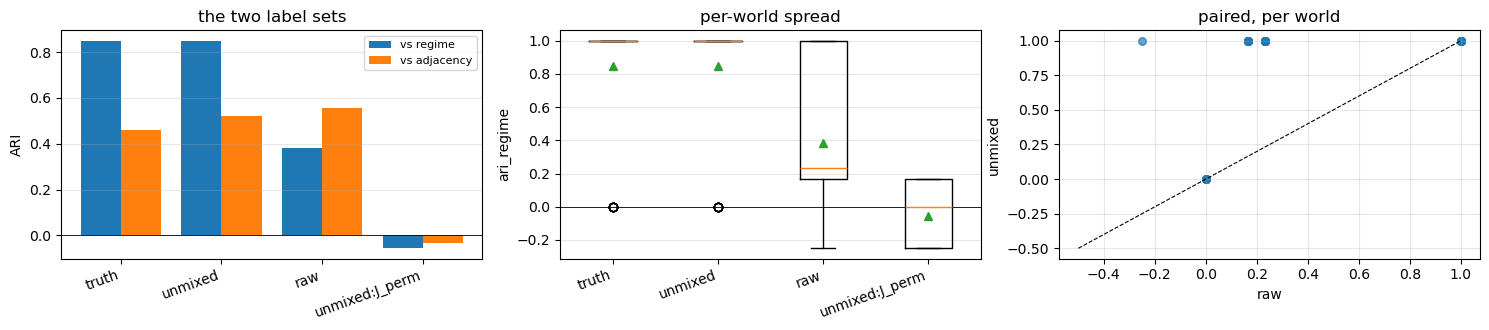

In [11]:
# =====================================================================
# 6. controls across the pinned set
# =====================================================================
SAN = J.clustering_sanity(WORLDS, DISTRICTS, placement="variance",
                          arm="J_pre", k=2, key="pre", axis="land_use")
tab = SAN.groupby("signal")[["ari_regime", "ari_adjacency"]].agg(
    ["mean", "std", "size"]).round(3)
display(tab)

ORD = ["truth", "unmixed", "raw", "unmixed:J_perm"]
present = [s for s in ORD if s in set(SAN.signal)]
m = SAN.groupby("signal")[["ari_regime", "ari_adjacency"]].mean().reindex(present)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
x = np.arange(len(present))
ax[0].bar(x - .2, m.ari_regime, .4, label="vs regime")
ax[0].bar(x + .2, m.ari_adjacency, .4, label="vs adjacency")
ax[0].axhline(0, color="k", lw=.6)
ax[0].set(xticks=x, ylabel="ARI", title="the two label sets")
ax[0].set_xticklabels(present, rotation=20, ha="right")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3, axis="y")

ax[1].boxplot([SAN.loc[SAN.signal == s, "ari_regime"].dropna()
               for s in present], showmeans=True)
ax[1].set(xticks=x + 1, ylabel="ari_regime", title="per-world spread")
ax[1].set_xticklabels(present, rotation=20, ha="right")
ax[1].axhline(0, color="k", lw=.6); ax[1].grid(alpha=.3, axis="y")

pv = SAN.pivot_table(index="sim_hash", columns="signal", values="ari_regime")
if {"unmixed", "raw"} <= set(pv.columns):
    ax[2].scatter(pv["raw"], pv["unmixed"], s=30, alpha=.7)
    ax[2].plot([-.5, 1], [-.5, 1], "k--", lw=.8)
    ax[2].set(xlabel="raw", ylabel="unmixed", title="paired, per world")
    ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [12]:
# --- the verdicts, derived ------------------------------------------------
L = J.Ledger()
g = SAN.groupby("signal")[["ari_regime", "ari_adjacency"]].mean()


def _get(sig, col):
    return float(g.loc[sig, col]) if sig in g.index else np.nan


ceil_, un, rw = (_get("truth", "ari_regime"), _get("unmixed", "ari_regime"),
                 _get("raw", "ari_regime"))
pm = _get("unmixed:J_perm", "ari_regime")

L.add("C1", "Is regime structure in the demand at all?", "ari_regime (truth)",
      ceil_, "YES" if ceil_ > 0.5 else "NO -- nothing to recover",
      "ceiling; clustering on true district demand")
L.add("C2", "Does unmixing recover it?", "ari_regime (unmixed / ceiling)",
      un / ceil_ if ceil_ else np.nan,
      "YES" if ceil_ and un > 0.8 * ceil_ else "partially",
      f"unmixed {un:.3f} vs ceiling {ceil_:.3f}")
L.add("C3", "Does the observational signal recover it?", "ari_regime (raw)",
      rw, "NO" if rw < 0.5 * max(ceil_, 1e-9) else "partly",
      "raw = district-aggregated own sensors, the confounded estimand")
adj_un = _get("unmixed", "ari_adjacency")
L.add("C4", "Is the gain a relabelling of adjacency?",
      "ari_adjacency (unmixed)", adj_un,
      "NO -- confound removed, not renamed"
      if adj_un < 0.25 and un > rw else "CANNOT RULE OUT",
      "the de-confounding claim needs regime UP (unmixed > raw) AND "
      "adjacency AT CHANCE in absolute terms, not merely lower than raw's -- "
      f"raw sits at {_get('raw', 'ari_adjacency'):+.3f} for comparison")
L.add("C5", "Does the falsification control collapse?",
      "ari_regime (J_perm)", pm,
      "YES" if pm < 0.25 else "NO -- clustering is not driven by the Jacobian",
      "same inverse, district columns shuffled; chance is ~0")
display(L.sheet())
SAN.to_csv(OUT / "clustering_sanity.csv", index=False)
print(f"-> {OUT/'clustering_sanity.csv'}")

,exp,question,metric,value,answer
0,C1,Is regime structure in the demand at all?,ari_regime (truth),0.850000,YES
1,C2,Does unmixing recover it?,ari_regime (unmixed / ceiling),1.000000,YES
2,C3,Does the observational signal recover it?,ari_regime (raw),0.382853,NO
3,C4,Is the gain a relabelling of adjacency?,ari_adjacency (unmixed),0.519231,CANNOT RULE OUT
4,C5,Does the falsification control collapse?,ari_regime (J_perm),-0.056250,YES


-> C:\Users\arthu\USPy\10_Mestrado\fedWater\data\08_reporting\jval\clustering_sanity.csv


In [18]:
WORLDS.columns

Index(['anchor_scale', 'beta', 'close_fraction', 'consumption_map',
       'drift_district', 'drift_seed_node', 'drift_to_income',
       'drift_to_land_use', 'n_months', 'sim_seed', 'variant', 'sim_hash',
       'status', 'usable', 'missing', 'dir', 'tag', 'cell', 'arm', 'studies',
       'dup'],
      dtype='object')

In [23]:
WORLDS[WORLDS['sim_hash'] == '021dcc84a2e2'][['tag', 'close_fraction', 'consumption_map',
       'drift_district', 'drift_seed_node', 'drift_to_income',
       'drift_to_land_use', 'n_months', 'variant', 'sim_hash',
         'studies']]

,tag,close_fraction,consumption_map,drift_district,drift_seed_node,drift_to_income,drift_to_land_use,n_months,variant,sim_hash,studies
14,Cli__LR_LR_LR_LR_LI__baseline,0.0,LR_LR_LR_LR_LI,District_C,59,low,industrial,48,baseline,021dcc84a2e2,s1_oddone


In [29]:
qwe = pd.read_parquet('..\\..\\data\\09_experiments\\jval_s1_oddone\\harvest\\dependence_pairs.parquet')
qwe.head() #[qwe['district_a'].str.contains('C') | qwe['district_b'].str.contains('C')]

,sim_hash,run_hash,level,kind,district_a,district_b,comm_floats_per_client,method,statistic,p_value,extra,q_value
0,021dcc84a2e2,84df74504fc2,T,aer_latent,District_A,District_B,916200,rv,0.027260,0.004975,NaN,0.004975
1,021dcc84a2e2,84df74504fc2,T,aer_latent,District_A,District_B,916200,trajectory_dcor,0.221158,0.019608,NaN,0.019608
2,021dcc84a2e2,84df74504fc2,T,aer_latent,District_A,District_B,916200,partial_rv,0.001000,0.666667,NaN,0.740741
3,021dcc84a2e2,84df74504fc2,T,aer_latent,District_A,District_B,916200,pc1_lagged_xcorr,0.034701,0.348259,6.0,0.696517
4,021dcc84a2e2,84df74504fc2,T,aer_latent,District_A,District_C,916200,rv,0.023390,0.004975,NaN,0.004975


In [32]:
import glob, os
import pandas as pd, numpy as np
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

BASE = os.path.join("..", "..", "data", "09_experiments")

exp_dirs = sorted(d for d in glob.glob(os.path.join(BASE, "*jval*")) if os.path.isdir(d))
print(f"{len(exp_dirs)} experiments found:", [os.path.basename(d) for d in exp_dirs])

def _load(exp_dir, fname):
    p = os.path.join(exp_dir, "harvest", fname)
    if not os.path.exists(p):
        print(f"  missing {fname} in {os.path.basename(exp_dir)}")
        return None
    df = pd.read_parquet(p)
    df.insert(0, "experiment", os.path.basename(exp_dir))
    return df

pairs   = pd.concat([d for d in (_load(e, "dependence_pairs.parquet")   for e in exp_dirs) if d is not None], ignore_index=True)
summary = pd.concat([d for d in (_load(e, "dependence_summary.parquet") for e in exp_dirs) if d is not None], ignore_index=True)

# WORLDS already in memory -> just index it for lookup
gt = WORLDS.drop_duplicates("sim_hash").set_index("sim_hash")["drift_district"]
pairs = pairs.assign(abs_stat=pairs["statistic"].abs())

def coupling_rank(g, true_drift):
    """Mean |statistic| to every peer, per district; low = weakly coupled -> suspected drifter."""
    long = pd.concat([
        g[["district_a", "district_b", "abs_stat"]].rename(columns={"district_a": "d", "district_b": "peer"}),
        g[["district_b", "district_a", "abs_stat"]].rename(columns={"district_b": "d", "district_a": "peer"}),
    ])
    s = long.groupby("d")["abs_stat"].mean().sort_values()   # ascending: weakest first
    rank = (list(s.index).index(true_drift) + 1) if true_drift in s.index else np.nan
    return s.index[0], rank, len(s)

def cluster_split(g, true_drift):
    """2-cluster districts on 1-normalized|statistic|; True if the drifter lands alone in the minority group."""
    d = sorted(set(g.district_a) | set(g.district_b))
    idx = {x: i for i, x in enumerate(d)}
    n = len(d)
    M = np.zeros((n, n))
    for r in g.itertuples():
        M[idx[r.district_a], idx[r.district_b]] = M[idx[r.district_b], idx[r.district_a]] = r.abs_stat
    if n < 3 or M.max() == 0:
        return np.nan
    dist = 1 - M / M.max()
    np.fill_diagonal(dist, 0)
    Z = linkage(squareform(dist, checks=False), method="average")
    labels = fcluster(Z, t=2, criterion="maxclust")
    lab_of = dict(zip(d, labels))
    counts = pd.Series(labels).value_counts()
    minority = [x for x, l in lab_of.items() if l == counts.idxmin()]
    return bool(true_drift in minority and len(minority) < n / 2)

rows = []
for (exp, sim, run, level, method), g in pairs.groupby(["experiment", "sim_hash", "run_hash", "level", "method"]):
    true_drift = gt.get(sim)
    if true_drift is None:
        continue
    predicted, rank, n_d = coupling_rank(g, true_drift)
    grouped_ok = cluster_split(g, true_drift)
    rows.append(dict(experiment=exp, sim_hash=sim, run_hash=run, level=level, method=method,
                      predicted_weakest=predicted, true_drift=true_drift,
                      rank_of_true=rank, n_districts=n_d,
                      hit_at_1=int(rank == 1), reciprocal_rank=1 / rank,
                      grouped_correctly=grouped_ok))
attribution = pd.DataFrame(rows)

# per experiment/run detail -> scoreboard per experiment x level x method
scoreboard_by_experiment = (attribution.groupby(["experiment", "level", "method"])
    .agg(runs=("run_hash", "nunique"),
         hit_at_1_rate=("hit_at_1", "mean"),
         mrr=("reciprocal_rank", "mean"),
         mean_rank=("rank_of_true", "mean"),
         cluster_accuracy=("grouped_correctly", "mean"))
    .sort_values(["experiment", "mrr"], ascending=[True, False]))

# global scoreboard across all experiments, for a method-level comparison
scoreboard_overall = (attribution.groupby(["level", "method"])
    .agg(runs=("sim_hash", "nunique"),
         hit_at_1_rate=("hit_at_1", "mean"),
         mrr=("reciprocal_rank", "mean"),
         cluster_accuracy=("grouped_correctly", "mean"))
    .sort_values("mrr", ascending=False))

# quick scan: MRR per experiment x method (level T only, most granular signal)
pivot_mrr = attribution[attribution.level == "T"].pivot_table(
    index="experiment", columns="method", values="reciprocal_rank", aggfunc="mean")

print(scoreboard_overall)

6 experiments found: ['jval_beta', 'jval_coupling', 'jval_income', 'jval_s1_equalised', 'jval_s1_oddone', 'jval_s2_split']
                        runs  hit_at_1_rate       mrr  cluster_accuracy
level method                                                           
P     rv                  40       0.818182  0.897727          0.818182
      trajectory_dcor     40       0.772727  0.863636          0.772727
T     pc1_lagged_xcorr    40       0.272727  0.521591          0.363636
      rv                  40       0.250000  0.502273          0.250000
      trajectory_dcor     40       0.250000  0.491667          0.250000
      partial_rv          40       0.204545  0.444318          0.227273


In [33]:
cov_cols = ["close_fraction", "drift_to_income", "drift_to_land_use",
            "drift_seed_node", "n_months", "variant", "studies", "tag"]
world_cov = WORLDS.drop_duplicates("sim_hash").set_index("sim_hash")[cov_cols]

def district_scores(g):
    long = pd.concat([
        g[["district_a", "district_b", "abs_stat"]].rename(columns={"district_a": "d", "district_b": "peer"}),
        g[["district_b", "district_a", "abs_stat"]].rename(columns={"district_b": "d", "district_a": "peer"}),
    ])
    return long.groupby("d")["abs_stat"].mean().sort_values()   # ascending: weakest peer first

p_rows = []
for (exp, sim, run, method), g in pairs[pairs.level == "P"].groupby(["experiment", "sim_hash", "run_hash", "method"]):
    td = gt.get(sim)
    if td is None or td not in set(g.district_a) | set(g.district_b):
        continue
    s = district_scores(g)
    others = s.drop(td)
    q_true = pd.concat([g.loc[g.district_a == td, "q_value"], g.loc[g.district_b == td, "q_value"]])
    p_rows.append(dict(experiment=exp, sim_hash=sim, run_hash=run, method=method,
                        true_drift=td, predicted=s.index[0],
                        rank=list(s.index).index(td) + 1,
                        margin=others.min() - s[td],          # >0: true drifter clearly weakest
                        frac_sig=(q_true < 0.05).mean()))      # was the true drifter even detected?
p_attr = pd.DataFrame(p_rows).join(world_cov, on="sim_hash")

# 1. seed-only vs structural sweep, per experiment
struct_cols = ["close_fraction", "drift_to_income", "drift_to_land_use", "variant", "n_months"]
sweep_kind = (p_attr.drop_duplicates(["experiment", "sim_hash"])
              .groupby("experiment")[struct_cols].nunique()
              .apply(lambda r: "seed-only" if (r == 1).all() else "structural", axis=1))
print(sweep_kind)

# 2. rank distribution per method (not just the mean)
print(p_attr.groupby(["method", "rank"]).size().unstack(fill_value=0))

# 3. confusion: when wrong, who does it pick instead?
for m in ["rv", "trajectory_dcor"]:
    print(m, "\n", pd.crosstab(p_attr.loc[p_attr.method == m, "true_drift"],
                                p_attr.loc[p_attr.method == m, "predicted"]))

# 4. margin distribution + its relationship to significance
print(p_attr.groupby("method")[["margin", "frac_sig"]].describe())

# 5. accuracy stratified by drift type / severity / world config
for col in ["drift_to_income", "drift_to_land_use", "variant"]:
    print(col, "\n", p_attr.groupby(["method", col])["rank"].apply(lambda r: (r == 1).mean()).unstack())

experiment
jval_beta             seed-only
jval_coupling        structural
jval_income          structural
jval_s1_equalised     seed-only
jval_s1_oddone       structural
jval_s2_split        structural
dtype: object
rank              1  2  3  4
method                      
rv               36  5  3  0
trajectory_dcor  34  5  3  2
rv 
 predicted   District_A  District_B  District_C  District_D  District_E
true_drift                                                            
District_A           9           0           0           0           0
District_B           0           6           0           0           0
District_C           0           0           8           0           1
District_D           0           0           0           3           6
District_E           0           0           1           0          10
trajectory_dcor 
 predicted   District_A  District_B  District_C  District_D  District_E
true_drift                                                            
Distr

In [34]:
tag_of = WORLDS.drop_duplicates("sim_hash").set_index("sim_hash")["tag"]

# --- wide map: one row per world/run, one column per (level, method) ---
map_table = (attribution
             .assign(level_method=lambda d: d.level + "_" + d.method)
             .pivot_table(index=["experiment", "sim_hash", "run_hash"],
                          columns="level_method", values="predicted_weakest", aggfunc="first"))

map_table.insert(0, "true_drift", map_table.index.get_level_values("sim_hash").map(gt))
map_table.insert(0, "tag", map_table.index.get_level_values("sim_hash").map(tag_of))

def highlight(row):
    cols = [c for c in row.index if c not in ("tag", "true_drift")]
    return (["", ""] +
            ["background-color:#c6efce" if row[c] == row["true_drift"]
             else "background-color:#ffc7ce" for c in cols])

styled_map = map_table.style.apply(highlight, axis=1)
styled_map   # green = method correctly named the drifted district, red = miss

# --- per-world hit-rate across runs (collapses seed replicates), by method ---
hit_by_world = (attribution.assign(hit=lambda d: d.predicted_weakest == d.true_drift)
                 .groupby(["experiment", "sim_hash", "level", "method"])["hit"].mean()
                 .unstack(["level", "method"]))
hit_by_world.insert(0, "tag", hit_by_world.index.get_level_values("sim_hash").map(tag_of))
hit_by_world.insert(0, "true_drift", hit_by_world.index.get_level_values("sim_hash").map(gt))
print(hit_by_world)

# --- overall miss list: exactly which (world, method) pairs got it wrong, with what margin ---
misses = (attribution.merge(
              p_attr[["experiment", "sim_hash", "run_hash", "method", "margin", "frac_sig"]],
              on=["experiment", "sim_hash", "run_hash", "method"], how="left")
          .query("predicted_weakest != true_drift")
          [["experiment", "sim_hash", "run_hash", "level", "method",
            "true_drift", "predicted_weakest", "rank_of_true", "margin", "frac_sig"]]
          .sort_values(["level", "method"]))
print(misses)

level                           true_drift                            tag  \
method                                                                      
experiment        sim_hash                                                  
jval_beta         2f848af2d6ac  District_D  Dli__LR_LR_LR_LR_LI__baseline   
                  4ffa4bda4b5c  District_D  Dli__LR_LR_LR_LR_LI__baseline   
                  7c18c548fcc4  District_D  Dli__LR_LR_LR_LR_LI__baseline   
jval_coupling     74e5d158e6e7  District_A  Ali__LR_LR_LR_LR_LI__baseline   
                  adce256d7a30  District_E  Elr__LR_LR_LR_LR_LI__isolated   
                  adfe1b1ae73a  District_E  Elr__LR_LR_LR_LR_LI__baseline   
                  b472a1a6af0b  District_A  Ali__LR_LR_LR_LR_LI__isolated   
jval_income       163515cc1a8a  District_E  Elr__LR_LR_LR_LR_HR__baseline   
                  262eba17b212  District_C  Chr__LR_LR_LR_LR_HR__baseline   
                  616a7f27accb  District_E  Elr__LR_LR_LR_LR_HR__baseline   

In [35]:
tag_of = WORLDS.drop_duplicates("sim_hash").set_index("sim_hash")["tag"]

# named prediction map (fixes the earlier 0/1 version)
map_table = (attribution
             .assign(level_method=lambda d: d.level + "_" + d.method)
             .pivot_table(index=["experiment", "sim_hash", "run_hash"],
                          columns="level_method", values="predicted_weakest", aggfunc="first"))
map_table.insert(0, "true_drift", map_table.index.get_level_values("sim_hash").map(gt))
map_table.insert(0, "variant", map_table.index.get_level_values("sim_hash").map(
    WORLDS.drop_duplicates("sim_hash").set_index("sim_hash")["variant"]))
print(map_table)

# D-vs-E diagnostic: raw per-district coupling score in every world where D truly drifted
focus = pairs[(pairs.level == "P") & (pairs.method.isin(["rv", "trajectory_dcor"]))
              & pairs["sim_hash"].map(gt).eq("District_D")]
for (sim, method), g in focus.groupby(["sim_hash", "method"]):
    print(method, sim, tag_of.get(sim), "\n", district_scores(g), "\n")

# and the D-E pairwise statistic specifically, isolated vs baseline
de = pairs[(pairs.level == "P") & pairs.district_a.eq("District_D") & pairs.district_b.eq("District_E")
           | (pairs.level == "P") & pairs.district_a.eq("District_E") & pairs.district_b.eq("District_D")]
de = de.assign(variant=de["sim_hash"].map(WORLDS.drop_duplicates("sim_hash").set_index("sim_hash")["variant"]))
print(de.groupby(["method", "variant"])["abs_stat"].describe())

level_method                                  variant  true_drift        P_rv  \
experiment        sim_hash     run_hash                                         
jval_beta         2f848af2d6ac 84df74504fc2  baseline  District_D  District_E   
                  4ffa4bda4b5c 84df74504fc2  baseline  District_D  District_D   
                  7c18c548fcc4 84df74504fc2  baseline  District_D  District_E   
jval_coupling     74e5d158e6e7 84df74504fc2  baseline  District_A  District_A   
                  adce256d7a30 84df74504fc2  isolated  District_E  District_E   
                  adfe1b1ae73a 84df74504fc2  baseline  District_E  District_E   
                  b472a1a6af0b 84df74504fc2  isolated  District_A  District_A   
jval_income       163515cc1a8a 84df74504fc2  baseline  District_E  District_E   
                  262eba17b212 84df74504fc2  baseline  District_C  District_C   
                  616a7f27accb 84df74504fc2  baseline  District_E  District_C   
                  cb4df28db5

In [40]:
from sklearn.metrics import silhouette_score

def cluster_detail(g, true_drift, linkage_method="average"):
    d = sorted(set(g.district_a) | set(g.district_b))
    idx = {x: i for i, x in enumerate(d)}
    n = len(d)
    M = np.zeros((n, n))
    for r in g.itertuples():
        M[idx[r.district_a], idx[r.district_b]] = M[idx[r.district_b], idx[r.district_a]] = r.abs_stat
    if n < 3 or M.max() == 0:
        return None
    dist = 1 - M / M.max()
    np.fill_diagonal(dist, 0)
    Z = linkage(squareform(dist, checks=False), method=linkage_method)
    labels = fcluster(Z, t=2, criterion="maxclust")
    lab_of = dict(zip(d, labels))
    counts = pd.Series(labels).value_counts()
    minority = [x for x, l in lab_of.items() if l == counts.idxmin()]
    sil = silhouette_score(dist, labels, metric="precomputed") if len(set(labels)) > 1 else np.nan
    return dict(n_districts=n, minority_size=len(minority), minority=tuple(sorted(minority)),
                is_singleton=len(minority) == 1, drift_in_minority=true_drift in minority,
                drift_isolated_alone=(true_drift in minority and len(minority) == 1),
                silhouette=sil)

rows = []
for (exp, sim, run, method), g in pairs[(pairs.level == "P") & pairs.method.isin(["rv", "trajectory_dcor"])].groupby(
        ["experiment", "sim_hash", "run_hash", "method"]):
    td = gt.get(sim)
    if td is None:
        continue
    for lm in ["average", "complete", "ward"]:
        det = cluster_detail(g, td, linkage_method=lm)
        if det is None:
            continue
        det.update(experiment=exp, sim_hash=sim, run_hash=run, method=method, linkage=lm, true_drift=td)
        rows.append(det)
cluster_quality = pd.DataFrame(rows)

# membership accuracy vs strict "isolated alone" accuracy, per linkage choice
print(cluster_quality.groupby(["method", "linkage"]).agg(
    n=("sim_hash", "nunique"), membership_acc=("drift_in_minority", "mean"),
    singleton_rate=("is_singleton", "mean"), isolated_correctly=("drift_isolated_alone", "mean"),
    mean_silhouette=("silhouette", "mean")))

# when the split disagrees with the rank-based heuristic: who else is in the minority group?
print(cluster_quality[(cluster_quality.linkage == "average") & (cluster_quality.minority_size > 1)]
      [["experiment", "sim_hash", "method", "true_drift", "minority", "drift_in_minority"]])

# robustness: does the correct/incorrect call change across linkage methods?
stability = (cluster_quality.pivot_table(index=["method", "sim_hash", "run_hash"], columns="linkage",
                                          values="drift_in_minority").nunique(axis=1) == 1)
print(stability.groupby("method").mean())  # 1.0 = linkage-choice-independent verdict

# silhouette: clean split vs muddy split, by correctness
print(cluster_quality[cluster_quality.linkage == "average"].groupby(["method", "drift_in_minority"])["silhouette"].describe())

                           n  membership_acc  singleton_rate  \
method          linkage                                        
rv              average   40        0.818182        1.000000   
                complete  40        0.840909        0.931818   
                ward      40        0.840909        0.931818   
trajectory_dcor average   40        0.772727        0.977273   
                complete  40        0.772727        0.909091   
                ward      40        0.772727        0.909091   

                          isolated_correctly  mean_silhouette  
method          linkage                                        
rv              average             0.818182         0.557189  
                complete            0.772727         0.554568  
                ward                0.772727         0.563327  
trajectory_dcor average             0.750000         0.558599  
                complete            0.704545         0.557690  
                ward                0.7

skipping 1 world(s) with no ground truth in WORLDS: ['e1743cff36a7']


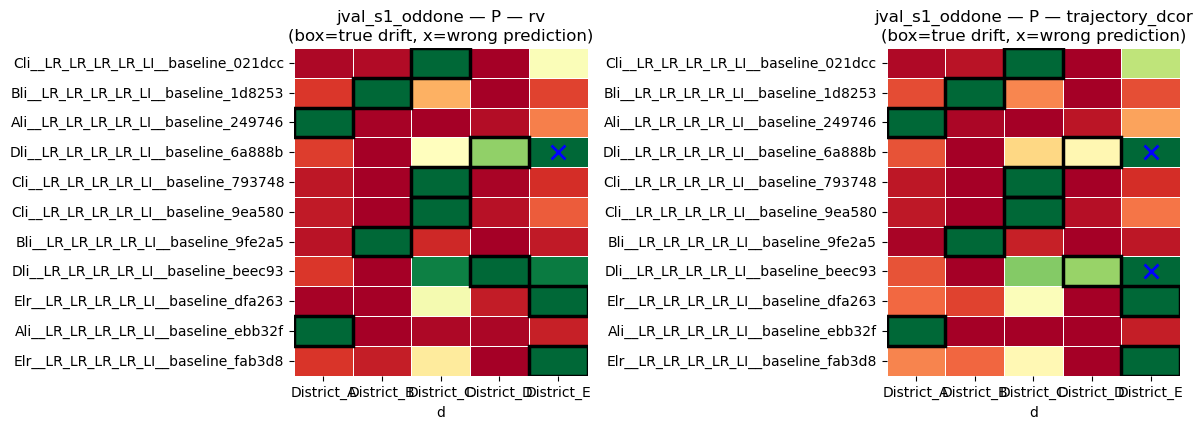

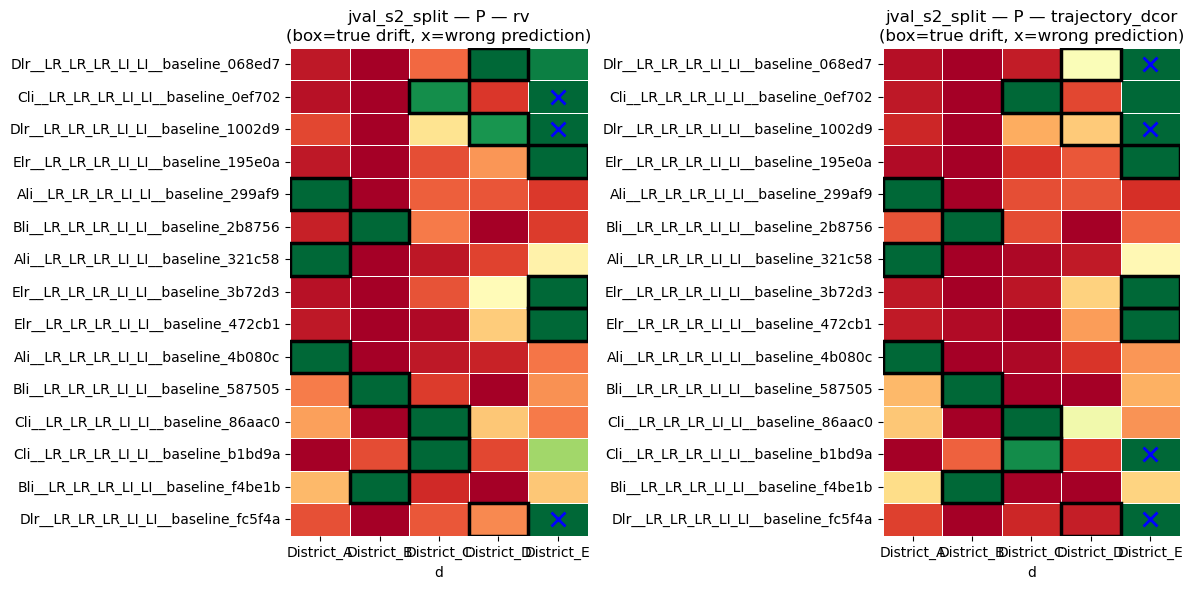

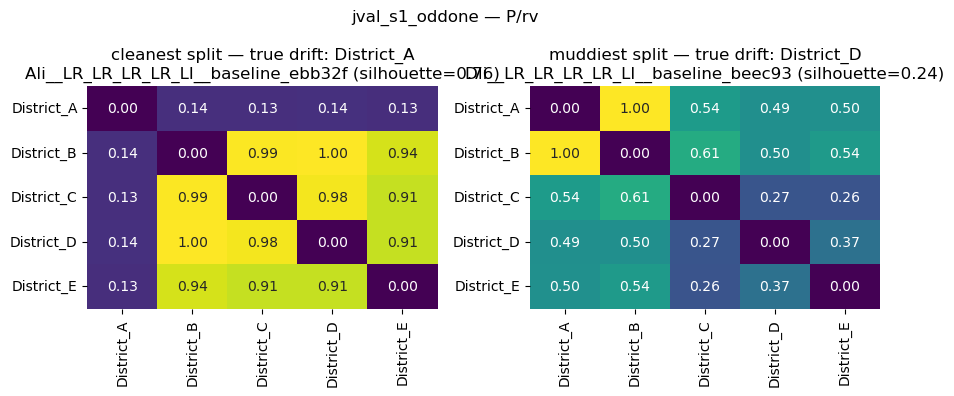

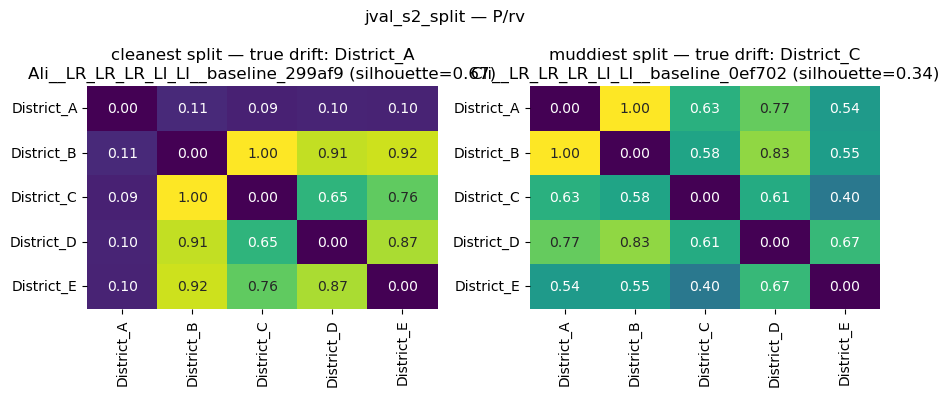

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

tag_of = WORLDS.drop_duplicates("sim_hash").set_index("sim_hash")["tag"]

def short_label(sim):
    t = tag_of.get(sim, "unknown_tag")
    return f"{t}_{sim[:6]}"

def build_matrix(g):
    d = sorted(set(g.district_a) | set(g.district_b))
    M = pd.DataFrame(0.0, index=d, columns=d)
    for r in g.itertuples():
        M.loc[r.district_a, r.district_b] = M.loc[r.district_b, r.district_a] = r.abs_stat
    return M

def district_scores(g):
    long = pd.concat([
        g[["district_a", "district_b", "abs_stat"]].rename(columns={"district_a": "d", "district_b": "peer"}),
        g[["district_b", "district_a", "abs_stat"]].rename(columns={"district_b": "d", "district_a": "peer"}),
    ])
    return long.groupby("d")["abs_stat"].mean().sort_values()

def plot_overview(exp_name, level="P", methods=("rv", "trajectory_dcor")):
    sub_exp = pairs_dedup[(pairs_dedup.experiment == exp_name) & (pairs_dedup.level == level)]
    sims = sorted(sub_exp.sim_hash.unique())
    skipped = [s for s in sims if gt.get(s) is None]
    if skipped:
        print(f"skipping {len(skipped)} world(s) with no ground truth in WORLDS: {skipped}")
    sims = [s for s in sims if gt.get(s) is not None]

    fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), max(3, 0.4 * len(sims))))
    if len(methods) == 1:
        axes = [axes]
    for ax, method in zip(axes, methods):
        rows, truth, pred = {}, {}, {}
        for sim in sims:
            g = sub_exp[(sub_exp.sim_hash == sim) & (sub_exp.method == method)]
            if g.empty:
                continue
            s = district_scores(g)
            rows[sim], truth[sim], pred[sim] = s, gt[sim], s.index[0]
        if not rows:
            ax.set_visible(False)
            continue
        mat = pd.DataFrame(rows).T.reindex(columns=sorted(pd.DataFrame(rows).T.columns))
        norm = mat.sub(mat.min(1), axis=0).div(mat.max(1) - mat.min(1), axis=0)
        norm.index = [short_label(s) for s in norm.index]           # <-- tag_sim6 labels
        sns.heatmap(norm, cmap="RdYlGn_r", cbar=False, ax=ax, linewidths=0.5, linecolor="white")
        for i, sim in enumerate(mat.index):
            j_true = list(mat.columns).index(truth[sim])
            ax.add_patch(plt.Rectangle((j_true, i), 1, 1, fill=False, edgecolor="black", lw=2.5))
            if pred[sim] != truth[sim]:
                j_pred = list(mat.columns).index(pred[sim])
                ax.plot(j_pred + 0.5, i + 0.5, "x", color="blue", ms=10, mew=2)
        ax.set_title(f"{exp_name} — {level} — {method}\n(box=true drift, x=wrong prediction)")
        ax.set_ylabel("")
    plt.tight_layout(); plt.show()

plot_overview("jval_s1_oddone")
plot_overview("jval_s2_split")

def silhouette_for(sim, level, method):
    g = pairs_dedup[(pairs_dedup.sim_hash == sim) & (pairs_dedup.level == level) & (pairs_dedup.method == method)]
    if g.empty:
        return np.nan
    M = build_matrix(g)
    if M.values.max() == 0:
        return np.nan
    dist = 1 - M / M.values.max()
    np.fill_diagonal(dist.values, 0)
    Z = linkage(squareform(dist.values, checks=False), method="average")
    labels = fcluster(Z, t=2, criterion="maxclust")
    return silhouette_score(dist.values, labels, metric="precomputed") if len(set(labels)) > 1 else np.nan

def plot_best_worst(exp_name, level="P", method="rv"):
    sims = sorted(pairs_dedup[pairs_dedup.experiment == exp_name].sim_hash.unique())
    sims = [s for s in sims if gt.get(s) is not None]
    sil = pd.Series({s: silhouette_for(s, level, method) for s in sims}).dropna()
    if sil.empty:
        print(f"no valid silhouette scores for {exp_name}"); return
    best, worst = sil.idxmax(), sil.idxmin()
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    for ax, sim, tag_ in zip(axes, [best, worst], ["cleanest split", "muddiest split"]):
        g = pairs_dedup[(pairs_dedup.sim_hash == sim) & (pairs_dedup.level == level) & (pairs_dedup.method == method)]
        M = build_matrix(g)
        sns.heatmap(M / M.values.max(), annot=True, fmt=".2f", cmap="viridis", ax=ax, cbar=False)
        ax.set_title(f"{tag_} — true drift: {gt[sim]}\n{short_label(sim)} (silhouette={sil[sim]:.2f})")
    plt.suptitle(f"{exp_name} — {level}/{method}")
    plt.tight_layout(); plt.show()

plot_best_worst("jval_s1_oddone")
plot_best_worst("jval_s2_split")

In [49]:
import numpy as np, pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

DISTRICT_ORDER = ["District_A", "District_B", "District_C", "District_D", "District_E"]

def parse_archetype_map(consumption_map: str) -> dict:
    tokens = consumption_map.split("_")
    return dict(zip(DISTRICT_ORDER[:len(tokens)], tokens))

worlds_arch = WORLDS.drop_duplicates("sim_hash").set_index("sim_hash").copy()
worlds_arch["archetype_map"] = worlds_arch["consumption_map"].apply(parse_archetype_map)

def build_matrix(g):
    d = sorted(set(g.district_a) | set(g.district_b))
    M = pd.DataFrame(0.0, index=d, columns=d)
    for r in g.itertuples():
        M.loc[r.district_a, r.district_b] = M.loc[r.district_b, r.district_a] = r.abs_stat
    return M

def cluster_labels(M, k):
    dist = 1 - M / (M.values.max() or 1)
    np.fill_diagonal(dist.values, 0)
    Z = linkage(squareform(dist.values, checks=False), method="average")
    return dict(zip(M.index, fcluster(Z, t=k, criterion="maxclust")))

def score_recovery(exclude_drifter: bool):
    rows = []
    for (exp, sim, run, level, method), g in pairs_dedup.groupby(
            ["experiment", "sim_hash", "run_hash", "level", "method"]):
        if sim not in worlds_arch.index:
            continue
        arch = worlds_arch.loc[sim, "archetype_map"]
        drifter = gt.get(sim)
        exclude = {drifter} if (exclude_drifter and drifter) else set()
        M_full = build_matrix(g)
        districts = [d for d in M_full.index if d not in exclude]
        true_labels = [arch.get(d, "NA") for d in districts]
        if len(set(true_labels)) < 2 or "NA" in true_labels or M_full.values.max() == 0:
            continue
        k = len(set(true_labels))
        pred = cluster_labels(M_full.loc[districts, districts], k)
        pred_labels = [pred[d] for d in districts]
        rows.append(dict(experiment=exp, sim_hash=sim, run_hash=run, level=level, method=method,
                          k=k, ari=adjusted_rand_score(true_labels, pred_labels),
                          nmi=normalized_mutual_info_score(true_labels, pred_labels)))
    return pd.DataFrame(rows)

with_drifter    = score_recovery(exclude_drifter=False)
without_drifter = score_recovery(exclude_drifter=True)

print("archetype recovery, drifted district INCLUDED (closest to 'as-is' state):")
print(with_drifter.groupby(["level", "method"])[["ari", "nmi"]].mean().sort_values("ari", ascending=False))

print("\narchetype recovery, drifted district EXCLUDED (proxy for 'undisturbed' structure):")
print(without_drifter.groupby(["level", "method"])[["ari", "nmi"]].mean().sort_values("ari", ascending=False))

# how much does the drifted district specifically hurt structural recovery?
delta = (without_drifter.groupby(["level", "method"])["ari"].mean()
         - with_drifter.groupby(["level", "method"])["ari"].mean())
print("\nARI gain from excluding the drifter (bigger = drift distorts structure more):\n", delta.sort_values(ascending=False))

# the explicit two-group design — most direct test of "does clustering match the mapping"
print("\njval_s2_split only:")
print(with_drifter[with_drifter.experiment == "jval_s2_split"]
      .groupby(["level", "method"])["ari"].agg(["mean", "count"]))

archetype recovery, drifted district INCLUDED (closest to 'as-is' state):
                             ari       nmi
level method                              
P     trajectory_dcor   0.146635  0.379330
      rv                0.134615  0.372346
T     pc1_lagged_xcorr -0.100160  0.199850
      partial_rv       -0.204327  0.148951
      rv               -0.213942  0.138854
      trajectory_dcor  -0.213942  0.138854

archetype recovery, drifted district EXCLUDED (proxy for 'undisturbed' structure):
                             ari       nmi
level method                              
P     trajectory_dcor   0.515152  0.686548
      rv                0.505051  0.680710
T     pc1_lagged_xcorr -0.136364  0.267991
      partial_rv       -0.171717  0.246844
      rv               -0.202020  0.229331
      trajectory_dcor  -0.202020  0.229331

ARI gain from excluding the drifter (bigger = drift distorts structure more):
 level  method          
P      rv                  0.370435
       traject